<a href="https://colab.research.google.com/github/Adams-ke/PYTHON/blob/main/K_Means_Intuition_builder_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from google.colab import files

In [ ]:
uploaded = files.upload()


Saving income.csv to income.csv


In [ ]:
dataset = pd.read_csv('income.csv')
dataset.head()

,Name,Age,Income($)
0,Rob,27,70000
1,Michael,29,90000
2,Mohan,29,61000
3,Ismail,28,60000
4,Kory,42,150000


In [ ]:
df = dataset.drop('Name', axis=1 )
df.head()

,Age,Income($)
0,27,70000
1,29,90000
2,29,61000
3,28,60000
4,42,150000


Scaling the features

In [ ]:
from  sklearn.preprocessing import MinMaxScaler

In [ ]:
scaler = MinMaxScaler()
df_scaled = scaler.fit_transform(df)
df_scaled = pd.DataFrame(df_scaled, columns= df.columns)

In [ ]:
df_scaled.head()

,Age,Income($)
0,0.058824,0.213675
1,0.176471,0.384615
2,0.176471,0.136752
3,0.117647,0.128205
4,0.941176,0.897436


Visualize the data


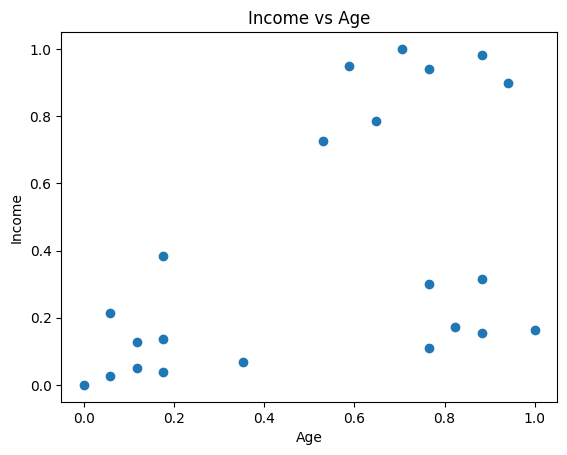

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(df_scaled['Age'], df_scaled['Income($)'])
plt.xlabel('Age')
plt.ylabel('Income')
plt.title('Income vs Age')
plt.show()

Use the K_means


In [ ]:
from sklearn.cluster import KMeans
km = KMeans(n_clusters=3)
km

KMeans(n_clusters=3)

In [ ]:
y_predicted = km.fit_predict(df_scaled)
y_predicted


array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2],
      dtype=int32)

Grouped our data into 3 (0,1,2)

In [ ]:
df['Cluster'] = y_predicted
df.head(3)

,Age,Income($),Cluster
0,27,70000,0
1,29,90000,0
2,29,61000,0


/tmp/ipykernel_15928/538781782.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Text(0.5, 1.0, 'Income vs Age')

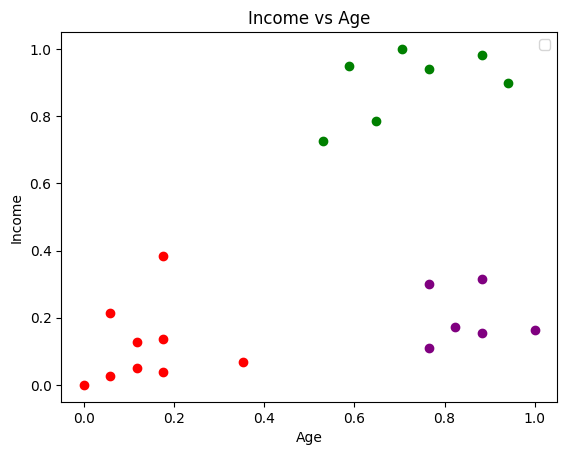

In [ ]:
df1 = df_scaled[df.Cluster==0]
df2 = df_scaled[df.Cluster==1]
df3 = df_scaled[df.Cluster==2]

plt.scatter(df1.Age, df1['Income($)'], color='red')
plt.scatter(df2.Age, df2['Income($)'], color='green')
plt.scatter(df3.Age, df3['Income($)'], color='purple')

plt.legend()
plt.xlabel('Age')
plt.ylabel('Income')
plt.title('Income vs Age')


Adding Centroids (cluster centers)


In [ ]:
km.cluster_centers_

array([[0.1372549 , 0.11633428],
       [0.72268908, 0.8974359 ],
       [0.85294118, 0.2022792 ]])

Text(0.5, 1.0, 'Income vs Age')

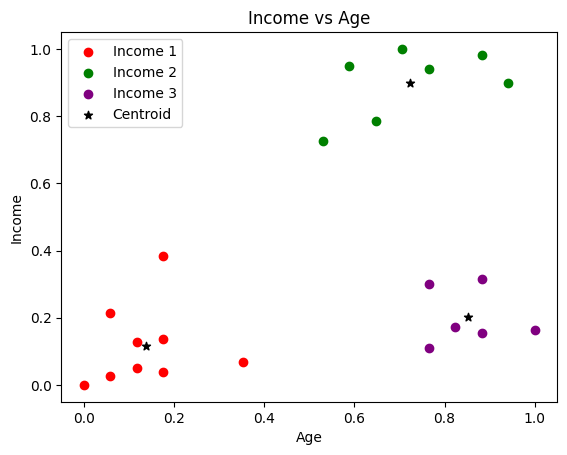

In [ ]:
plt.scatter(df1.Age, df1['Income($)'], color='red', label='Income 1')
plt.scatter(df2.Age, df2['Income($)'], color='green', label='Income 2')
plt.scatter(df3.Age, df3['Income($)'], color='purple',  label='Income 3')

plt.scatter(km.cluster_centers_[:,0 ], km.cluster_centers_[:,1], color='black', marker='*', label='Centroid')

plt.legend()
plt.xlabel('Age')
plt.ylabel('Income')
plt.title('Income vs Age')


FINDING THE MOST OPTIMAL VALUE OF K

Most of the time the data will not be as simple to identify the number of clustersas this seems to be.

The ELBOW methord comes in handy, plotting the SSE and
corresponding values of K

In [17]:
k_rng = range(1,10)
sse=[]

for k in k_rng:
  km = KMeans(n_clusters=k)
  km.fit(df_scaled)
  sse.append(km.inertia_) #this is a parameter in kmeans that equates to sse

In [18]:
sse # the SSE alues equated above by the inertia parameter of the kmeans

[5.434011511988179,
 2.091136388699078,
 0.4750783498553097,
 0.3698658919234834,
 0.32443403666256826,
 0.21055478995472496,
 0.21124270149977728,
 0.1397684499538816,
 0.10497488680620906]

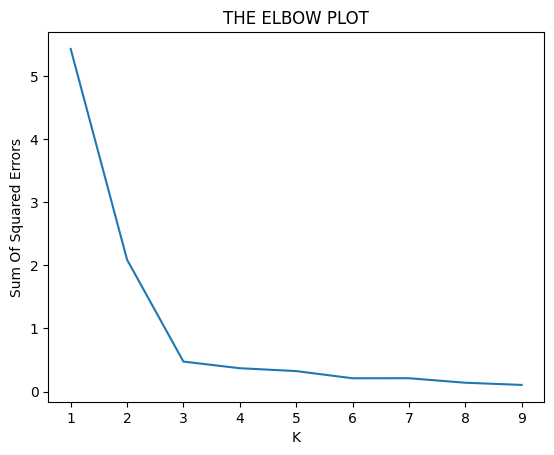

In [20]:
plt.title('THE ELBOW PLOT')
plt.xlabel('K')
plt.ylabel('Sum Of Squared Errors')
plt.plot(k_rng,sse)


With that it is easier to identify that the best value for K is 3. just like the bend  of the elbow, the point in the graph that has the most drastic change in the slope indicates where the optimal value of K is on the X axis.
